# ACV: refrigerant-leak localisation -- peer z-score index

One ranking of the 8 cars per file, most to least likely to carry the leak. Nothing is
fitted. Two indicators are each turned into a **robust z-score against the car's 7 peers**
and averaged with equal weights; the car with the highest mean z is the most suspicious.
With six labelled files there is nothing to fit weights against that would not just
memorise the files -- an XGBoost trial on the same features scored a perfect 1.0
leave-one-case-out, but the fitted trees were one signal (how much hotter a car runs than
its siblings, in three encodings) plus a few splits, which is no evidence of anything at
n = 6. So the design is deliberately parameter-free.

**Why peer comparison.** Every car in a file sees the same weather, the same schedule and
the same train-wide setpoint, so the other seven cars are a free control group. A car
whose cabin runs warmer, or lags the setpoint more, than all of its siblings is the
candidate. This is the same idea as fleet-based anomaly detection in condition monitoring:
score each unit's strangeness against its peers, with no labelled history required.

**Pipeline**: load each file under one canonical schema -> per car, reduce the whole
recording to two indicators -> for each indicator, z-score each car against the median and
robust spread (1.4826 x MAD) of the *other seven* -> average a car's z over the indicators
it has -> sort descending (highest mean z = most suspicious).

What this notebook settled on, in one line each:

- **Indicators** -- `hot` (mean indoor temperature over the file) and `gap` (indoor minus
  cooling setpoint, averaged over the rows where the car is in a cooling mode).
- **Scoring rule** -- leave-one-out robust z against the 7 peers. Unlike a rank it says
  *how far* a car sits from the rest, so a clear outlier and a marginal leader are no
  longer indistinguishable.
- **Spread floor** -- the peer spread is never taken below `MIN_SCALE` = 0.02 degrees C.
  The sensor steps in 0.5 degrees C, so on a short window the peers can agree almost
  exactly and a difference of one quantisation step would give an absurd z. The floor
  leaves every whole-file score unchanged; it only bites on the quarter-of-a-file checks.
- **Missing** -- excluded, never defaulted. A car with no reading for an indicator gets no
  z for it; a car with no data at all ranks last (cars 05-08 of case 04).
- **Weights** -- equal.
- **Scoring** -- the official `(n - (r - 1)) / n` over all 8 cars, with the faulty car's
  rank taken as the *midpoint of its tie group* rather than the first hit, because sorting
  a tied score otherwise credits a rank the data never earned.
- **Data handling** -- literal `0` readings in the temperature/setpoint columns become NaN
  at load time (`ps3_data.ACV_TREAT_ZERO_AS_MISSING`, one flag). They coincide with the
  `Invalid` flags (row for row in case 01, identical counts in cases 02-03 and the Test
  file). Case 04's ~55 extra telemetry columns are ignored: the Test file follows the
  standard 8-parameter schema, so nothing learned from them could be used.
- **Dropped indicators** -- `maj` (agreement with the train's majority running mode) and
  `inval` (count of `Invalid` flags) were in an earlier version and are out; section 6
  shows why, and section 7 re-checks it with a train/validation split.

**Read sections 4 and 5 before trusting the headline number.** The labelled score was
measured on the same six files the indicators were chosen on, so it shows that the signal
exists, not what the Test file will score.

In [1]:
# Make the notebook runnable from any working directory (project root, PS3, or
# this folder). Jupyter sets the kernel's cwd from wherever it was launched, and
# `acv_composite` only imports if its folder is on sys.path -- so find it rather
# than assuming. Data loading then goes through acv_features -> ps3_data, which
# resolve the dataset from their own location.
import pathlib
import sys

def _module_dir(filename="acv_composite.py"):
    start = pathlib.Path.cwd().resolve()
    for base in [start, *start.parents]:
        for candidate in [base, base / "ACV subproblem", base / "PS3" / "ACV subproblem"]:
            if (candidate / filename).is_file():
                return candidate
    raise FileNotFoundError(
        f"{filename} not found from {start} -- open the notebook from inside the "
        f"repository, or add its folder to sys.path manually.")

MODULE_DIR = _module_dir()
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))
print(f"modules: {MODULE_DIR}")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import acv_composite as ac
import acv_features as af
import acv_plots as ap

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110

modules: C:\Users\keith\PycharmProjects\NebulaX-Hackathon-ProblemStatement\PS3\ACV subproblem


## 1. The data

Seven files (six labelled, one Test), 8 cars each, sampled every 30 s (case 04: every
10 s). Loading goes through `acv_features.load_case`, which folds the differently-named
columns of cases 04-06 onto the standard parameter names and mirrors each `.xlsx` to
Parquet on first read -- case 04's 483 columns take well over a minute through
`openpyxl`, then well under a second.

In [2]:
af.case_shapes()[["case", "n_rows", "n_cols", "n_cars", "duration_h", "median_dt_s"]]

,case,n_rows,n_cols,n_cars,duration_h,median_dt_s
0,acv_case_01.xlsx,6999,67,8,92.825000,30.0
1,acv_case_02.xlsx,9187,67,8,95.583333,30.0
2,acv_case_03.xlsx,8310,67,8,90.725000,30.0
3,acv_case_04.xlsx,22262,483,8,85.569444,10.0
4,acv_case_05.xlsx,6972,67,8,89.675000,30.0
5,acv_case_06.xlsx,3263,67,8,63.291667,30.0
6,acv_test_case.xlsx,9082,67,8,95.991667,30.0


## 2. The two indicators

| | computed as | more suspicious when | why |
|---|---|---|---|
| `hot` | mean `Indoor Average Temperature` over the file | higher | a leak cuts cooling capacity, so the cabin runs warmer than its siblings' under the same weather and schedule |
| `gap` | mean of `Indoor - ACV Control Temperature (Cooling)` over the rows where that car's own running mode is a cooling state | higher | cooling is commanded train-wide, so this is how well *this car's* compressor executes a command all 8 were given |

Both are then turned into a leave-one-out z-score:

`z(car) = (x_car - median(peers)) / max(1.4826 x MAD(peers), 0.02)`

where *peers* are the other seven cars. A z of 0 means "indistinguishable from the rest";
+5 means five robust standard deviations warmer than the peer median. The mean of the two
z-scores is the index.

`hot` uses the mean, not the median: the temperature sensor steps in 0.5 degrees C, so a
whole-file median ties most cars (all eight in case 02) and gives no information, while
the mean still separates them.

Worked example, case 02 (faulty car 02): the two indicator values, their z-scores, and
the mean z.

In [3]:
ind, z, mz = ac.rank_case("acv_case_02.xlsx")
pd.concat([ind[["indoor_mean", "cooling_gap_mean"]].round(3),
           z.round(2).add_prefix("z_"), mz.rename("mean_z").round(2)], axis=1)

,indoor_mean,cooling_gap_mean,z_hot,z_gap,mean_z
01,23.747,0.169,-1.10,-0.67,-0.89
02,24.038,0.478,4.69,7.91,6.30
03,23.956,0.372,3.13,5.01,4.07
04,23.776,0.168,-0.28,-0.68,-0.48
05,23.686,0.083,-2.42,-1.93,-2.18
06,23.797,0.190,0.07,-0.36,-0.15
07,23.828,0.218,0.52,0.78,0.65
08,23.792,0.215,-0.06,0.59,0.26


The z-scores show the size of the lead: the faulty car's mean z can be compared with the
best other car's directly, where a rank would only say "first".

## 3. Result on the six labelled files

In [4]:
summary = ac.case_summary()
print(f"mean expected score: {summary['score'].mean():.3f}   (random ranking: {ap.RANDOM_BASELINE:.3f})")
summary

mean expected score: 0.979   (random ranking: 0.562)


,case,ranked_cars,faulty,best,worst,score
0,acv_case_01.xlsx,01|02|03|04|07|06|08|05,01,1,1,1.000
1,acv_case_02.xlsx,02|03|07|08|06|04|01|05,02,1,1,1.000
2,acv_case_03.xlsx,03|02|04|08|01|07|05|06,03,1,1,1.000
3,acv_case_04.xlsx,04|01|02|03|05|06|07|08,01,2,2,0.875
4,acv_case_05.xlsx,04|02|07|01|06|03|08|05,04,1,1,1.000
5,acv_case_06.xlsx,06|08|04|02|03|05|01|07,06,1,1,1.000


`best`/`worst` are the faulty car's best and worst position given its tie group; `score`
uses the midpoint. Five files have the faulty car first. In case 04 the faulty car (01)
is second: only cars 01-04 carry data there, and car 04 outscores it, so 0.875 is the
figure. That file is the honest warning of what a subtle fault looks like -- the faulty
car's `hot` is indistinguishable from its siblings' (z of 0.33, section 5) and car 04
outscores it overall (see the table below).

In [5]:
labels = af.label_map()
rows = []
for case in af.TRAIN_CASES:
    _, _, m = ac.rank_case(case)
    f = labels[case]
    other = m.drop(f).dropna()
    rows.append({"case": case[:-5], "faulty": f,
                 "faulty_mean_z": round(m[f], 2),
                 "best_other_car": other.idxmax(), "best_other_mean_z": round(other.max(), 2),
                 "margin": round(m[f] - other.max(), 2)})
pd.DataFrame(rows)

,case,faulty,faulty_mean_z,best_other_car,best_other_mean_z,margin
0,acv_case_01,01,13.41,02,3.32,10.10
1,acv_case_02,02,6.30,03,4.07,2.23
2,acv_case_03,03,4.24,02,1.04,3.20
3,acv_case_04,01,2.66,04,10.25,-7.59
4,acv_case_05,04,3.68,02,3.30,0.37
5,acv_case_06,06,15.49,08,1.73,13.76


`margin` is the faulty car's mean z minus the best other car's. Positive = a clear first
place; the size shows how clear. Narrow positive margins mean the "1.000" scores in those
files are closer calls than a rank alone suggests. A negative margin (case 04) is a miss;
there the z-scores rest on only four cars with data, so the peer spread is tiny and the
values are large but unreliable.

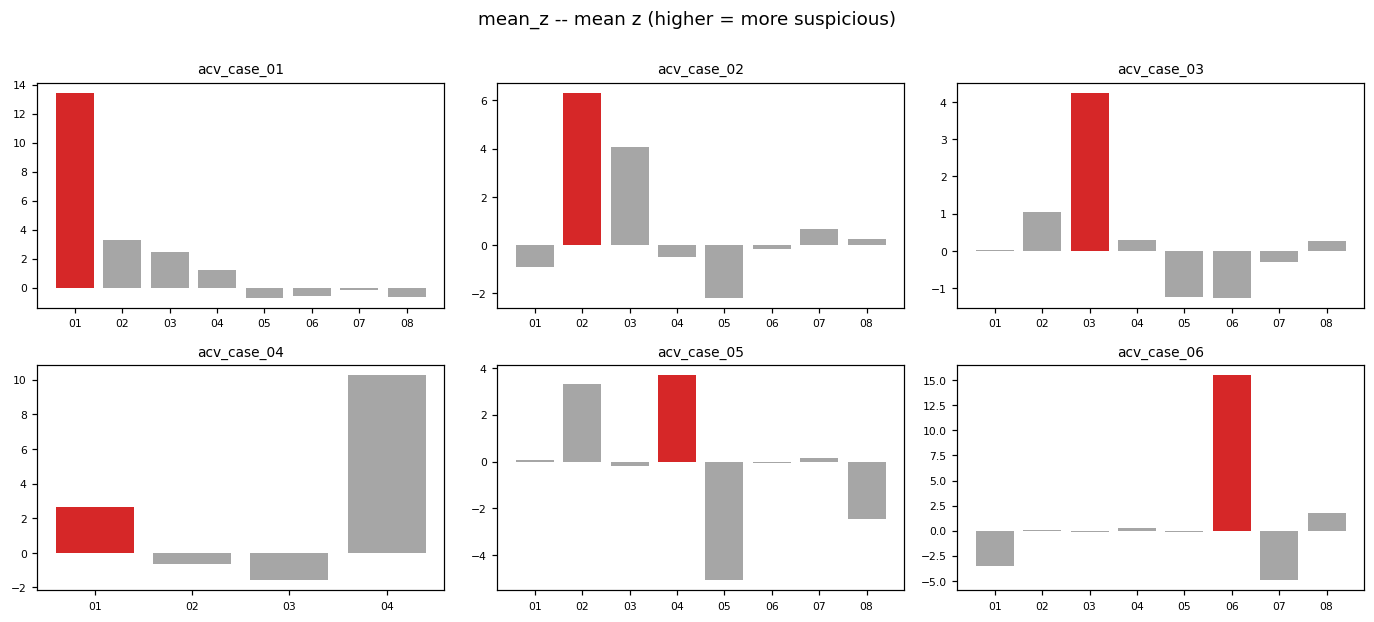

In [6]:
bars = []
for case in af.TRAIN_CASES:
    _, _, m = ac.rank_case(case)
    bars += [{"case": case, "car": car, "param": "mean z (higher = more suspicious)",
              "mean_z": v} for car, v in m.items()]
ap.plot_stat_by_car(pd.DataFrame(bars), "mean_z",
                    "mean z (higher = more suspicious)", cases=af.TRAIN_CASES);

## 4. Does each indicator matter?

Each indicator alone, and the combination, scored the same tie-aware way.

In [7]:
rows = []
for case in af.TRAIN_CASES:
    ind = ac.indicators(case)
    row = {"case": case[:-5]}
    for k in ac.INDICATORS:
        _, mk = ac.peer_z(ind, use=(k,))
        row[k] = ac.tie_aware(mk, labels[case], n_total=len(mk))["score"]
    _, both = ac.peer_z(ind)
    row["hot+gap"] = ac.tie_aware(both, labels[case], n_total=len(both))["score"]
    rows.append(row)
alone = pd.DataFrame(rows).set_index("case")
alone.loc["mean"] = alone.mean()
alone.round(3)

,hot,gap,hot+gap
case,,,
acv_case_01,1.000,1.000,1.000
acv_case_02,1.000,1.000,1.000
acv_case_03,1.000,1.000,1.000
acv_case_04,0.875,0.875,0.875
acv_case_05,1.000,1.000,1.000
acv_case_06,1.000,1.000,1.000
mean,0.979,0.979,0.979


`hot` and `gap` each put the faulty car first in the same files, so the two are largely
redundant on the labelled data -- both are ways of seeing a cabin that cools less well.
The combination is kept because it costs nothing here and averages out single-indicator
quirks on a file where they differ. The honest reading: this is essentially **one signal,
measured twice**.

## 5. Is the signal real, or an artifact of how missing values are handled?

Nothing in this pipeline fills a value in. What it does do -- mask zeros to NaN, skip NaNs
inside means, floor the peer spread -- can each shape a ranking, so each is tested.

**Variants.** A keeps the zeros as 0; B (the pipeline above) turns them to NaN; C keeps
only the timestamps where every car with data is fully observed -- non-blank, non-zero,
not `Invalid` -- so nothing depends on how a missing or glitched reading is treated. Cells
are `best-worst rank (expected score)` of the faulty car.

In [8]:
t_comp, t_ind = ac.variant_tables()
t_comp

,case,faulty,A raw zeros,B zeros->NaN,C clean rows only
0,acv_case_01,01,1-1 (1.000),1-1 (1.000),1-1 (1.000)
1,acv_case_02,02,1-1 (1.000),1-1 (1.000),1-1 (1.000)
2,acv_case_03,03,1-1 (1.000),1-1 (1.000),1-1 (1.000)
3,acv_case_04,01,2-2 (0.875),2-2 (0.875),2-2 (0.875)
4,acv_case_05,04,1-1 (1.000),1-1 (1.000),1-1 (1.000)
5,acv_case_06,06,1-1 (1.000),1-1 (1.000),1-1 (1.000)


The faulty car's z on each indicator, variant B / variant C:

In [9]:
t_ind

,case,faulty,hot,gap
0,acv_case_01,01,7.93 / 8.56,18.90 / 18.96
1,acv_case_02,02,4.69 / 4.76,7.91 / 7.55
2,acv_case_03,03,3.38 / 3.37,5.11 / 5.10
3,acv_case_04,01,0.33 / 0.33,5.00 / 5.00
4,acv_case_05,04,3.58 / 3.58,3.78 / 3.78
5,acv_case_06,06,15.52 / 15.52,15.45 / 15.45


Does the signal hold across the recording, or come from one stretch? The faulty car's
z in each quarter of the file. Values are large where the seven peers are nearly
identical over a short window, so read them as "clearly above" or "not", not as exact.

In [10]:
ac.persistence_table().round(2)

,case,indicator,Q1,Q2,Q3,Q4
0,acv_case_01,hot,2.48,0.52,4.98,45.86
1,acv_case_01,gap,3.21,4.35,4.97,62.36
2,acv_case_02,hot,1.03,2.71,13.17,4.28
3,acv_case_02,gap,1.75,2.60,13.17,4.00
4,acv_case_03,hot,10.58,4.97,10.08,0.76
5,acv_case_03,gap,10.58,5.10,11.95,2.88
6,acv_case_04,hot,0.35,0.66,1.37,-0.19
7,acv_case_04,gap,1.64,3.87,0.08,0.94
8,acv_case_05,hot,0.76,2.54,0.41,3.66
9,acv_case_05,gap,0.71,2.23,0.39,3.70


**What the checks say**

- **The signal is not an artifact of missing-value handling.** Rankings are the same
  across A, B and C (or differ only in a tie), and the faulty car's z on each indicator
  barely moves between B and C.
- **`hot` and `gap` largely agree**, so a good score on the labelled files is one signal's
  worth of evidence, not two.
- **Persistence varies by file.** A chronic fault should stay high in every quarter; where
  the faulty car's z drops toward zero in a quarter, the signal is intermittent there.
- **Case 04 is the failure to watch.** Its faulty car is not separable on `hot` (z of
  0.33), which is the most likely shape of a subtle fault in Test.

## 6. Why `maj` and `inval` were dropped

Both were in an earlier four-indicator rank composite. Each fails on evidence in this data.

- **`inval`** counts rows where `ACV Information Valid` is `Invalid`. In cases 01-03 it is
  large or nonzero on the faulty car and close to zero elsewhere, but it is silent in
  cases 05-06 and does not exist in case 04. Crucially, in the **Test** file it fires on
  five cars, not one, so the labelled files' "exclusive to the faulty car" pattern does
  not hold there.
- **`maj`** is how often the car's running mode equals the train's majority mode. On an
  `Invalid` row the car reports mode `Invalid`, which is by construction a mismatch, so it
  double-counts `inval`. Excluding those rows removes the double count -- and then it ranks
  the faulty car mid-table in case 06 (tied 4th to 6th) instead of near the top.

In [11]:
# How many of the faulty car's majority-mismatch rows are just Invalid rows?
ac.overlap_table()

,case,faulty,invalid_rows,mismatch_rows,both,mode_on_invalid_rows
0,acv_case_01,01,25,64,25,{'Invalid': 25}
1,acv_case_02,02,44,45,44,{'Invalid': 44}
2,acv_case_03,03,1,2,1,{'Invalid': 1}
3,acv_case_05,04,0,11,0,{}
4,acv_case_06,06,0,1,0,{}


In [12]:
# Faulty car's raw n_invalid and frac_majority against the median of its peers.
rows = []
for case in af.TRAIN_CASES:
    ind = ac.indicators(case)
    f = labels[case]
    peers = ind.drop(f)
    rows.append({"case": case[:-5], "faulty": f,
                 "n_invalid faulty": ind.loc[f, "n_invalid"],
                 "n_invalid peer median": peers["n_invalid"].median(),
                 "frac_majority faulty": round(ind.loc[f, "frac_majority"], 4),
                 "frac_majority peer median": round(peers["frac_majority"].median(), 4)})
pd.DataFrame(rows)

,case,faulty,n_invalid faulty,n_invalid peer median,frac_majority faulty,frac_majority peer median
0,acv_case_01,01,25.0,0.0,0.9938,1.0000
1,acv_case_02,02,44.0,0.0,0.9999,0.9999
2,acv_case_03,03,1.0,0.0,0.9999,0.9942
3,acv_case_04,01,NaN,NaN,0.5736,0.8620
4,acv_case_05,04,0.0,0.0,0.9983,1.0000
5,acv_case_06,06,0.0,0.0,0.9996,0.9996


In the table above, `n_invalid` is 0 on the faulty car in cases 05 and 06 and missing in 04,
and `frac_majority` (Invalid rows excluded) is not consistently lower on the faulty car
than on its peers, so neither can carry a ranking. The `inval` pattern in Test is
below.

## 7. Tuning on a train / validation split

The method has no fitted parameters, but it does have choices: which indicators to use,
how much each counts, and the spread floor. This section treats them as settings to tune
and checks the choice honestly with a train/validation split.

**Search space.** All four candidate indicators (`hot`, `gap`, `inval`, `maj`), each with
weight 0, 0.5 or 1 (at least one non-zero), crossed with four spread floors -- 320
settings. A setting's score is the mean tie-aware expected score over the files it is
evaluated on. A car with no score for the chosen indicators ranks with the other no-score
cars at the bottom.

**Validation.** Every possible 4-train / 2-validation split of the six labelled files (15
folds), and leave-one-case-out (6 folds) as a cross-check. In each fold the best setting
on the training files is picked and then scored on the held-out files it never saw. Where
several settings tie on the training files, the simplest is taken: fewest active
indicators, then a floor nearest 0.02. The comparison is the fixed `hot + gap`, floor 0.02
setting of the final method.

In [13]:
import itertools

KEYS = ["hot", "gap", "inval", "maj"]
COLS = {"hot": ("indoor_mean", 1), "gap": ("cooling_gap_mean", 1),
        "inval": ("n_invalid", 1), "maj": ("frac_majority", -1)}   # -1: lower = more suspicious
FLOORS = [0.005, 0.02, 0.05, 0.1]
CASES = af.TRAIN_CASES
IND = {c: ac.indicators(c) for c in CASES}

def zscores(ind, floor):
    """Leave-one-out robust z of every candidate indicator, at one spread floor."""
    out = {}
    for k, (col, sign) in COLS.items():
        x, z = ind[col], pd.Series(np.nan, index=ind.index)
        for car in ind.index:
            if pd.isna(x[car]):
                continue
            peers = x.drop(car).dropna()
            if peers.empty:
                continue
            scale = 1.4826 * (peers - peers.median()).abs().median()
            if scale < 1e-9:
                scale = peers.std(ddof=0)
            z[car] = sign * (x[car] - peers.median()) / max(scale, floor)
        out[k] = z
    return pd.DataFrame(out)

Z = {(c, f): zscores(IND[c], f) for c in CASES for f in FLOORS}
CONFIGS = [(w, f) for w in itertools.product([0, 0.5, 1], repeat=4) if sum(w) > 0 for f in FLOORS]

def case_score(case, cfg):
    weights, floor = cfg
    z, w = Z[(case, floor)], pd.Series(cfg[0], index=KEYS)
    idx = (z.fillna(0) * w).sum(axis=1) / z.notna().mul(w).sum(axis=1).replace(0, np.nan)
    n, faulty = len(idx), labels[case]
    if pd.isna(idx[faulty]):                       # no score: shares the last places
        k = int(idx.isna().sum())
        return (n - ((n - k) + (k + 1) / 2 - 1)) / n
    return ac.tie_aware(idx, faulty, n_total=n)["score"]

# settings x cases matrix of expected scores
S = pd.DataFrame({cfg: {c: case_score(c, cfg) for c in CASES} for cfg in CONFIGS}).T
DEFAULT = ((1, 1, 0, 0), 0.02)
print(f"{len(CONFIGS)} settings x {len(CASES)} cases; final method {DEFAULT}: "
      f"mean {S.loc[[DEFAULT]].mean(axis=1).iloc[0]:.3f}")

320 settings x 6 cases; final method ((1, 1, 0, 0), 0.02): mean 0.979


In [14]:
def pick(train):
    """Best mean score on `train`; ties -> fewest active indicators, floor nearest 0.02."""
    m = S[train].mean(axis=1)
    return min(m[m == m.max()].index, key=lambda c: (sum(1 for x in c[0] if x), abs(c[1] - 0.02), c))

def cross_validate(splits):
    rows = []
    for val in splits:
        train = [c for c in CASES if c not in val]
        cfg = pick(train)
        m = S[train].mean(axis=1)
        rows.append({"validation": "/".join(v[9:11] for v in val),
                     "picked (hot,gap,inval,maj)": cfg[0], "floor": cfg[1],
                     "tied on train": int((m == m.max()).sum()),
                     "train score": round(S.loc[[cfg], train].mean(axis=1).iloc[0], 3),
                     "val score (picked)": round(S.loc[[cfg], val].mean(axis=1).iloc[0], 3),
                     "val score (final method)": round(S.loc[[DEFAULT], val].mean(axis=1).iloc[0], 3)})
    return pd.DataFrame(rows)

cv15 = cross_validate([list(v) for v in itertools.combinations(CASES, 2)])
cv15

,validation,"picked (hot,gap,inval,maj)",floor,tied on train,train score,val score (picked),val score (final method)
0,01/02,"(0.5, 0, 0, 0.5)",0.02,61,1.0,1.000,1.000
1,01/03,"(0.5, 0, 0, 0.5)",0.02,66,1.0,1.000,1.000
2,01/04,"(0, 0.5, 0, 0)",0.02,277,1.0,0.938,0.938
3,01/05,"(0.5, 0, 0, 0.5)",0.02,61,1.0,1.000,1.000
4,01/06,"(0, 0, 0.5, 0.5)",0.02,77,1.0,0.750,1.000
5,02/03,"(0.5, 0, 0, 0.5)",0.02,66,1.0,1.000,1.000
6,02/04,"(0, 0.5, 0, 0)",0.02,277,1.0,0.938,0.938
7,02/05,"(0.5, 0, 0, 0.5)",0.02,61,1.0,1.000,1.000
8,02/06,"(0, 0, 0.5, 0.5)",0.02,77,1.0,0.750,1.000
9,03/04,"(0, 0.5, 0, 0)",0.02,288,1.0,0.938,0.938


In [15]:
cv6 = cross_validate([[c] for c in CASES])
summary = pd.DataFrame({
    "folds": [len(cv15), len(cv6)],
    "val score (picked)": [cv15["val score (picked)"].mean(), cv6["val score (picked)"].mean()],
    "val score (final method)": [cv15["val score (final method)"].mean(),
                                 cv6["val score (final method)"].mean()]},
    index=["4 train / 2 val, all splits", "leave-one-case-out"]).round(3)
print(f"random ranking: {ap.RANDOM_BASELINE:.3f}")
summary

random ranking: 0.562


,folds,val score (picked),val score (final method)
"4 train / 2 val, all splits",15,0.896,0.979
leave-one-case-out,6,0.896,0.979


In [16]:
# Every setting on the full six files: how much do the choices matter?
full = S.mean(axis=1)
print(f"settings scoring exactly the best full-data score: {int((full == full.max()).sum())} of {len(full)}")
print(f"final method: {full[DEFAULT]:.3f}   best setting: {full.max():.3f}   worst: {full.min():.3f}")
single = {"hot only": (1, 0, 0, 0), "gap only": (0, 1, 0, 0), "hot + gap": (1, 1, 0, 0),
          "+ inval": (1, 1, 1, 0), "+ maj": (1, 1, 0, 1), "all four": (1, 1, 1, 1),
          "inval only": (0, 0, 1, 0), "maj only": (0, 0, 0, 1)}
tab = pd.DataFrame({name: S.loc[[(w, 0.02)]].iloc[0] for name, w in single.items()}).T
tab.columns = [c[9:11] for c in tab.columns]
tab.insert(0, "mean", tab.mean(axis=1))
tab.round(3)

settings scoring exactly the best full-data score: 61 of 320
final method: 0.979   best setting: 1.000   worst: 0.781


,mean,01,02,03,04,05,06
hot only,0.979,1.0,1.0,1.0,0.875,1.000,1.000
gap only,0.979,1.0,1.0,1.0,0.875,1.000,1.000
hot + gap,0.979,1.0,1.0,1.0,0.875,1.000,1.000
+ inval,0.979,1.0,1.0,1.0,0.875,1.000,1.000
+ maj,0.979,1.0,1.0,1.0,0.875,1.000,1.000
all four,0.979,1.0,1.0,1.0,0.875,1.000,1.000
inval only,0.781,1.0,1.0,1.0,0.562,0.562,0.562
maj only,0.833,1.0,1.0,0.5,1.000,1.000,0.500


**What the tuning says.** It does not change the model, and that is the useful result.

- **Selecting a setting on the training files does worse on validation than not selecting.**
  Many settings (61 to 293 of 320, depending on the fold) score a perfect 1.0 on any four
  files, so the training score cannot choose among them and the pick is decided by the
  tie-break. That sometimes lands on `inval` and `maj`, which fail badly when the file they
  were not tuned on is held out.
- **`hot` and `gap` carry the result.** At equal weight, `hot` alone, `gap` alone and every
  combination with `inval` and/or `maj` all score 0.979 on the full data. Used alone,
  `inval` (0.781) and `maj` (0.833) are the worst, and they fail on different files, so
  neither is a stable signal.
- **`maj` is not useless: 61 of the 320 settings reach 1.000 on the full data, better than
  the final method's 0.979, and every one of them includes `maj`.** `hot` + `maj` at equal
  weight gets all six files right. The whole gain is case 04, where the faulty car agrees
  with the majority running mode far less than its peers (0.574 against a peer median of
  0.862, section 6) -- with only four cars reporting there, that one file decides it.
  Dropping `maj` therefore costs case 04 (0.875 instead of 1.000) on the labelled files.
- **It is dropped anyway, as a judgement call.** Alone it is unstable (0.833: wrong way in
  case 03, mid-table in case 06), it double-counts `inval`, and its edge rests on one
  four-car file. In the folds above, the settings built around it were picked over and
  over and scored anywhere from 1.000 down to 0.500 on the held-out files, depending on
  which files were held out. If case 04's fault type is what Test contains, this choice
  would cost about 0.125.
- **The spread floor does not matter** on whole-file scores: 0.005 to 0.1 all give the
  same result.

This is the evidence for keeping the method parameter-free: there was nothing a
validation split could reliably calibrate, and it shows `inval` and `maj` were candidates
that were eliminated rather than assumed away. One caveat stands --
the indicators were shortlisted after looking at all six files, so the "final method"
column is not a held-out number, and no split of these six files can make it one.

## 8. Test file

No label, so nothing here can be scored. The Test file follows the standard schema: every
car carries both indicators.

In [17]:
ind_t, z_t, mz_t = ac.rank_case("acv_test_case.xlsx")
tbl = pd.concat([ind_t[["indoor_mean", "cooling_gap_mean"]].round(3),
                 z_t.round(2).add_prefix("z_"), mz_t.rename("mean_z").round(2)], axis=1)
tbl.sort_values("mean_z", ascending=False)

,indoor_mean,cooling_gap_mean,z_hot,z_gap,mean_z
01,24.197,0.125,1.29,5.73,3.51
03,24.161,-0.053,0.82,0.95,0.89
04,24.155,-0.078,0.74,0.20,0.47
07,24.113,-0.076,0.18,0.24,0.21
08,24.099,-0.088,-0.21,-0.20,-0.20
06,24.093,-0.113,-0.29,-0.95,-0.62
02,24.047,-0.173,-1.07,-2.56,-1.81
05,24.010,-0.185,-1.66,-2.87,-2.27


In [18]:
pd.DataFrame([{"file_id": "acv_test_case.xlsx", "ranked_cars": ac.ranked_cars(mz_t)}])

,file_id,ranked_cars
0,acv_test_case.xlsx,01|03|04|07|08|06|02|05


Exact ties in `ranked_cars` are ordered by car id, which is arbitrary.

**Is the ranking sensible?** A qualitative read of the Test data:

- **Car 01 first is well supported.** It is the only car with a positive `gap`, and it
  stands several peer-spreads clear of the other seven; its `hot` lead is smaller.
- **The lead builds over the recording.** Per quarter (below), car 01's gap is the highest
  of the eight from the second quarter on, and it leads by the most in the second half --
  what a car that has lost cooling capacity does as the load rises.
- **The effect is smaller than in the labelled files**, where the faulty car sat well
  above its siblings. This may be a subtler fault, so confidence in first place is
  "likely", not "certain".
- **Ranks 2 to 8 are mostly noise.** Cars 03, 04 and 07 are within about one z of the
  peer median and cannot be separated.

In [19]:
# Mean gap per car in each quarter of the Test file: does car 01 pull away?
q = pd.DataFrame({f"Q{b + 1}": ac.indicators("acv_test_case.xlsx", block=(b, 4))["cooling_gap_mean"]
                  for b in range(4)})
q.round(2)

,Q1,Q2,Q3,Q4
01,-0.46,-0.11,0.35,0.70
02,-0.51,-0.33,-0.17,0.32
03,-0.46,-0.25,-0.01,0.49
04,-0.52,-0.23,-0.03,0.46
05,-0.53,-0.32,-0.15,0.26
06,-0.51,-0.21,-0.08,0.34
07,-0.48,-0.23,-0.00,0.40
08,-0.53,-0.32,-0.02,0.50


**A competing candidate: car 04.** It has about 20 rows where the car reports `Invalid`,
against 0 to 2 for the others (table below). In cases 01 and 02 an Invalid burst like that
marked the faulty car, which makes car 04 the strongest alternative to car 01. It is not
in the index because `inval` fires on five cars here and was silent on the faulty car in
two labelled files, and car 04's temperature signals are unremarkable. Whether its Invalid
rows are a symptom of a failing unit or a communications glitch cannot be settled from
these columns; the raw rows around the bursts are the place to look.

In [20]:
w = ac._wide("acv_test_case.xlsx", True)
pd.DataFrame({"invalid_rows": (w["valid"] == "Invalid").sum(),
              "full_cooling_rows": (w["mode"] == "Full Cooling").sum()})

,invalid_rows,full_cooling_rows
01,0,74
02,0,80
03,1,80
04,19,31
05,2,35
06,1,26
07,2,17
08,0,1


Cars 01-03 spend far more time in `Full Cooling` than car 08, with cars 04-07 in between.
That looks like a train-position effect rather than a fault, so it is not used.

## What was tried and ruled out

Kept as pointers, not full sections. Numbers are as measured at the time, on the same six
labelled files.

- **A rank composite of four indicators** (`hot` as a median, `inval`, `gap`, `maj`, ranks
  averaged): 0.990 on the labelled files, but `maj` double-counted `inval` and the median
  `hot` tied most cars. Fixing both and re-scoring gave 0.958, and dropping `maj` and
  `inval` gave 0.979 -- the score of `gap` alone. The z-score version reproduces 0.979
  with an explainable margin.
- **XGBoost on per-(case, car) summary statistics**, leave-one-case-out: a perfect 1.0 with
  55 features and again with 7. Feature importance was concentrated in `resid_mean`,
  `resid_absmean` and `indoor_median_rank` -- three encodings of "hotter than siblings" --
  with `resid_absmean` earning 0.35 importance from 3 splits. At 40 training rows per fold
  that is a threshold rule on one signal, not a learned combination. Absolute cutoffs also
  transfer badly: the Test file's `gap` values are all near zero or negative, unlike the
  positive gaps of the labelled faulty cars.
- **Indoor-vs-outdoor relationships** (correlation over all rows, over cooling rows only,
  and the widening of `Outdoor - Indoor` after cooling starts): about 0.78-0.81 where
  computable, and computable in only 4 of 6 files -- in cases 05-06 only the end cars (01,
  08) have an outdoor sensor, so the faulty car has nothing to compare. Case 02 fails the
  correlation variants (7th of 8) and the transition-response one (8th of 8).
- **`ACV Setting Mode` rules** (`frac_majority`, `n_switch`) scored a perfect 1.0 in the
  single-statistic sweep off almost no transitions, since the field is nearly constant.
  Not trusted.
- **A per-car "desired temperature"**: `ACV Control Temperature (Cooling)` is one train-wide
  value within a file (all 8 cars share the same median) and changes only between files, so
  there is nothing to compare across cars.
- **`Load Halved`** only ever reads `Normal`.
- **Case 04's extra columns** (compressor faults, refrigerant pressures, ...): not explored.
  They exist only in that one file, and the Test file does not have them.

## Other approaches from industry and research

Peer comparison is the fleet-monitoring idea used here. Others, and why they were not
used:

- **Residual models** -- predict what a car *should* read from a fault-free model and flag
  the residual. A sibling-based predictor is a natural next step and an independent second
  signal; an outdoor-temperature predictor was tried above and fails on the missing sensors.
- **Physics or hybrid models and direct refrigerant-mass estimation** -- these need
  refrigerant-side pressures and temperatures, which only case 04 has.
- **Supervised classifiers** (neural nets, LightGBM) -- need many labelled faults; six is
  not enough.